In [1]:
import pandas as pd
import joblib

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/cleaned_job_postings.csv")

tfidf = joblib.load("../models/tfidf_vectorizer.pkl")

model = joblib.load("../models/xgboost_model.pkl")

X = tfidf.transform(df["text"])

y = df["fraudulent"]

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
pred = model.predict(X_test)

In [5]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3395
           1       0.96      0.64      0.77       181

    accuracy                           0.98      3576
   macro avg       0.97      0.82      0.88      3576
weighted avg       0.98      0.98      0.98      3576



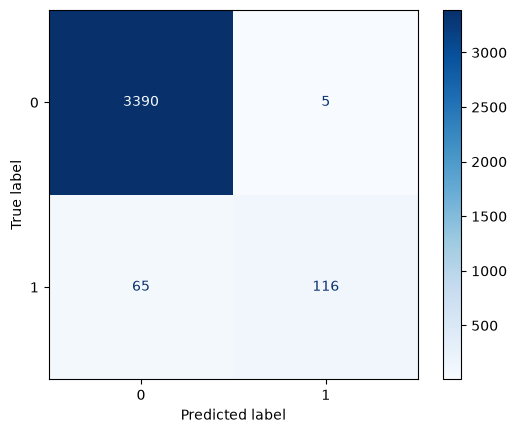

In [6]:
cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(cm)

disp.plot(cmap="Blues")

plt.show()